# Alexandria: limpieza conservadora, auditoría y candidatos a polimorfos

Este notebook prepara para análisis posterior el CSV que contiene cadenas SLICES generadas con la implementación oficial (`graph_method="econnn"`, `strategy=4`). El objetivo es auditar calidad, normalizar tipos sin alterar el significado químico de las cadenas, crear vistas básica/estricta y agrupar composiciones para identificar **candidatos** a polimorfos.

No se entrena ni tokeniza ChemBERTa, no se hace split y no se ejecuta `StructureMatcher`: el CSV no incluye las estructuras completas de pymatgen. Una composición repetida solo identifica entradas candidatas, no polimorfos confirmados. No se eliminan composiciones repetidas ni outliers y no se imputan targets.

Todos los artefactos creados por este notebook se guardan en `data/notebooks_processing/outputs/`. Si los CSV esperados ya existen, se crea una subcarpeta de ejecución fechada para conservar la versión anterior. El original se abre solo para lectura.

## Mapa de ejecución

1. Configuración y detección de paths; carga y auditoría inicial.
2. Normalización de strings/tipos; auditoría de ausentes, infinitos y duplicados.
3. Consistencia química/cristalográfica/energética y revisión de SLICES.
4. Flags físicos y estadísticos; composición de `quality_flags`.
5. Construcción de vistas limpias, singletons y candidatos; cálculo de ΔE preliminar.
6. Guardado de datasets, tablas de revisión, gráficos y resumen final.


## 1. Configuration

El lector prefiere `alexandria_valid.csv`. Si no está presente, busca el CSV validado producido por `to_SLICES.ipynb`. Los paths se construyen desde la ubicación del notebook para que funcione al abrir Jupyter desde el proyecto o desde esta carpeta.

In [3]:
import ast
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pymatgen.core import Composition

# Resolver la carpeta del notebook incluso si el kernel se inició desde otra carpeta.
SEARCH_BASES = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
NOTEBOOK_DIR = next(
    (base for base in SEARCH_BASES if (base / "to_SLICES.ipynb").is_file()),
    Path.cwd().resolve(),
)
OUTPUT_ROOT = NOTEBOOK_DIR / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_CANDIDATES = [
    OUTPUT_ROOT / "alexandria_valid.csv",
    OUTPUT_ROOT / "alexandria_00000_slices_valid.csv",
    NOTEBOOK_DIR / "alexandria_valid.csv",
    NOTEBOOK_DIR.parent / "alexandria_valid.csv",
]
INPUT_CSV = next((path.resolve() for path in INPUT_CANDIDATES if path.is_file()), None)
if INPUT_CSV is None:
    searched = "\n".join(str(path) for path in INPUT_CANDIDATES)
    raise FileNotFoundError(
        "No se encontró alexandria_valid.csv ni el CSV validado de to_SLICES. "
        f"Paths revisados:\n{searched}"
    )

EXPECTED_OUTPUTS = [
    "alexandria_clean_all.csv",
    "alexandria_clean_basic.csv",
    "alexandria_clean_strict.csv",
    "alexandria_singleton_compositions.csv",
    "alexandria_polymorph_candidates.csv",
    "alexandria_composition_summary.csv",
    "alexandria_rejected.csv",
]
collisions = [name for name in EXPECTED_OUTPUTS if (OUTPUT_ROOT / name).exists()]
if collisions:
    run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = OUTPUT_ROOT / f"cleaning_run_{run_stamp}"
    print("ADVERTENCIA: ya existen salidas con esos nombres; no se sobrescribirán:")
    print("\n".join(f"- {name}" for name in collisions))
else:
    OUTPUT_DIR = OUTPUT_ROOT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Input CSV:", INPUT_CSV)
print("Output directory:", OUTPUT_DIR)
print("SLICES configuration inherited from conversion: graph_method=econnn; strategy=4")


ADVERTENCIA: ya existen salidas con esos nombres; no se sobrescribirán:
- alexandria_clean_all.csv
- alexandria_clean_basic.csv
- alexandria_clean_strict.csv
- alexandria_singleton_compositions.csv
- alexandria_polymorph_candidates.csv
- alexandria_composition_summary.csv
- alexandria_rejected.csv
Input CSV: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/notebooks_processing/outputs/alexandria_00000_slices_valid.csv
Output directory: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/notebooks_processing/outputs/cleaning_run_20261005_212323
SLICES configuration inherited from conversion: graph_method=econnn; strategy=4


## 2. Load dataset

Se lee el CSV completo porque el shard esperado tiene aproximadamente 100 000 filas y el análisis requiere comparaciones entre filas. `source_row_index` permite rastrear cada registro hasta su fila de datos original (índice base cero; la cabecera no cuenta).

In [4]:
df = pd.read_csv(INPUT_CSV, low_memory=False)
input_column_count = len(df.columns)
df.insert(0, "source_row_index", np.arange(len(df), dtype=np.int64))
input_row_count = len(df)

print("Shape:", df.shape)
print("Columnas:")
print(df.columns.tolist())
print("Primeras filas:")
display(df.head())
print("Tipos detectados:")
display(df.dtypes.to_frame("dtype"))
print("Info:")
df.info(memory_usage="deep")


Shape: (99998, 38)
Columnas:
['source_row_index', 'mat_id', 'prototype_id', 'formula', 'reduced_formula', 'composition_key', 'composition', 'elements', 'n_elements', 'spg', 'nsites', 'volume', 'volume_per_atom', 'slices', 'slices_basic_valid', 'slices_valid', 'energy', 'energy_total', 'energy_corrected', 'energy_per_atom', 'energy_corrected_per_atom', 'e_form', 'e_above_hull', 'e_phase_separation', 'correction', 'band_gap_ind', 'band_gap_dir', 'total_mag', 'dos_ef', 'stress', 'decomposition', 'location', 'run_timestamp', 'conversion_success', 'conversion_error', 'structure_parsing_error', 'slices_conversion_error', 'slices_validation_error']
Primeras filas:


,source_row_index,mat_id,prototype_id,formula,reduced_formula,composition_key,composition,elements,n_elements,spg,...,dos_ef,stress,decomposition,location,run_timestamp,conversion_success,conversion_error,structure_parsing_error,slices_conversion_error,slices_validation_error
0,0,agm005737469,AB2C10_0_spg69,Sr(Cd5Rh)2,Sr(Cd5Rh)2,Cd10 Rh2 Sr1,"{""Cd"": 10.0, ""Rh"": 2.0, ""Sr"": 1.0}","[""Cd"", ""Rh"", ""Sr""]",3,69.0,...,6.497900,"[[7.6139755, 5.1e-07, 0.14952564], [5.1e-07, 7...",Cd41Rh8 Sr3Cd11 SrCd3Rh2,cgat_comp_2/ternaries/AB2C10/runs/batch-001/Sr...,"{""@class"": ""datetime"", ""@module"": ""datetime"", ...",True,NaN,NaN,NaN,NaN
1,1,agm002510391,ABC3_0_spg221,Li3CaPt,Li3CaPt,Ca1 Li3 Pt1,"{""Ca"": 1.0, ""Li"": 3.0, ""Pt"": 1.0}","[""Ca"", ""Li"", ""Pt""]",3,221.0,...,2.520410,"[[0.9447303, 0.0, 0.0], [0.0, 0.9447303, 0.0],...",Li2CaPt Li,high_throughput/perovskites/Li/Li3CaPt/xxx_02p...,"{""@class"": ""datetime"", ""@module"": ""datetime"", ...",True,NaN,NaN,NaN,NaN
2,2,agm004513860,AB2C3D4_7_spg115,Nd2TiGa4Pt3,Nd2TiGa4Pt3,Ga4 Nd2 Pt3 Ti1,"{""Ga"": 4.0, ""Nd"": 2.0, ""Pt"": 3.0, ""Ti"": 1.0}","[""Ga"", ""Nd"", ""Pt"", ""Ti""]",4,115.0,...,5.601462,"[[3.1229622, 0.0, 0.0], [0.0, 3.1229622, 0.0],...",Nd2Ga5Pt3 NdGaPt TiGaPt NdGa2,cgat_comp/quaternaries/AB2C3D4/runs/batch-000/...,"{""@class"": ""datetime"", ""@module"": ""datetime"", ...",True,NaN,NaN,NaN,NaN
3,3,agm003886200,ABC2_20_spg12,SrMnBr2,SrMnBr2,Br2 Mn1 Sr1,"{""Br"": 2.0, ""Mn"": 1.0, ""Sr"": 1.0}","[""Br"", ""Mn"", ""Sr""]",3,12.0,...,1.052251,"[[0.64611524, 0.0183197, -0.06288052], [0.0183...",Mn SrBr2,extra/batch-3000/Mn/MnBr2Sr/xxx_02a-00_agm0038...,"{""@class"": ""datetime"", ""@module"": ""datetime"", ...",True,NaN,NaN,NaN,NaN
4,4,agm034649907,AB2C3D6_251_spg12,Na2Tb3SmSe6,Na2Tb3SmSe6,Na2 Se6 Sm1 Tb3,"{""Na"": 2.0, ""Se"": 6.0, ""Sm"": 1.0, ""Tb"": 3.0}","[""Na"", ""Se"", ""Sm"", ""Tb""]",4,12.0,...,3.516617,"[[0.21772961, 0.01842787, -0.00535877], [0.018...",NaTb3(SmSe3)2 NaTbSe2,orbital/alignn_024/Na/Na2Se6SmTb3/xxx_02a-000_...,"{""@class"": ""datetime"", ""@module"": ""datetime"", ...",True,NaN,NaN,NaN,NaN


Tipos detectados:


,dtype
source_row_index,int64
mat_id,object
prototype_id,object
formula,object
reduced_formula,object
composition_key,object
composition,object
elements,object
n_elements,int64
spg,float64


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99998 entries, 0 to 99997
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   source_row_index           99998 non-null  int64  
 1   mat_id                     99998 non-null  object 
 2   prototype_id               99998 non-null  object 
 3   formula                    99998 non-null  object 
 4   reduced_formula            99998 non-null  object 
 5   composition_key            99998 non-null  object 
 6   composition                99998 non-null  object 
 7   elements                   99998 non-null  object 
 8   n_elements                 99998 non-null  int64  
 9   spg                        99998 non-null  float64
 10  nsites                     99998 non-null  int64  
 11  volume                     99998 non-null  float64
 12  volume_per_atom            99998 non-null  float64
 13  slices                     99998 non-nul

## 3. Initial audit

Se calculan los conteos iniciales y se muestran cifras históricas solo como referencia. Los resultados históricos no se usan como assertions: el CSV de entrada puede ser una versión distinta o haber sido regenerado.

In [5]:
REFERENCE_COUNTS = {
    "rows": 100000,
    "basic_valid": 99998,
    "strict_valid": 98394,
    "missing_slices": 2,
    "unique_compositions": 96588,
    "singleton_compositions": 93507,
    "compositions_ge_2": 3081,
    "compositions_ge_3": 255,
    "compositions_ge_5": 12,
    "max_structures_per_composition": 12,
}

def unique_count(column):
    return int(df[column].nunique(dropna=True)) if column in df.columns else None

initial_audit = {
    "rows": len(df),
    "columns": len(df.columns),
    "memory_mb_deep": round(df.memory_usage(index=True, deep=True).sum() / 1_000_000, 2),
    "unique_mat_id": unique_count("mat_id"),
    "unique_slices": unique_count("slices"),
    "unique_composition_key": unique_count("composition_key"),
}
print("Auditoría inicial:")
display(pd.Series(initial_audit, name="value").to_frame())
print("Referencia histórica (informativa; no es assertion):")
display(pd.Series(REFERENCE_COUNTS, name="expected_approximate").to_frame())


Auditoría inicial:


,value
rows,99998.00
columns,38.00
memory_mb_deep,164.41
unique_mat_id,99998.00
unique_slices,99998.00
unique_composition_key,96588.00


Referencia histórica (informativa; no es assertion):


,expected_approximate
rows,100000
basic_valid,99998
strict_valid,98394
missing_slices,2
unique_compositions,96588
singleton_compositions,93507
compositions_ge_2,3081
compositions_ge_3,255
compositions_ge_5,12
max_structures_per_composition,12


## 4. Normalize schema and types

Se requieren las seis columnas críticas. Los campos de texto se recortan, los marcadores textuales de nulos se convierten en `NaN` y para SLICES solo se compactan espacios consecutivos. No se cambia ningún token. Las conversiones numéricas se auditan antes/después para registrar strings numéricos ilegibles.

In [6]:
CRITICAL_COLUMNS = [
    "mat_id", "slices", "composition_key", "reduced_formula",
    "nsites", "energy_corrected_per_atom",
]
missing_critical_columns = [column for column in CRITICAL_COLUMNS if column not in df.columns]
if missing_critical_columns:
    raise ValueError(
        "Faltan columnas críticas requeridas: " + ", ".join(missing_critical_columns)
    )

STRING_COLUMNS = [
    "mat_id", "prototype_id", "formula", "reduced_formula", "composition_key", "slices"
]
NULL_TEXT = {"none", "nan", "null", "<na>"}

def normalize_text_value(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text or text.casefold() in NULL_TEXT:
        return np.nan
    return text

for column in STRING_COLUMNS:
    if column in df.columns:
        df[column] = df[column].map(normalize_text_value)
# El único cambio permitido dentro de SLICES es colapsar whitespace.
df["slices"] = df["slices"].map(
    lambda value: " ".join(value.split()) if isinstance(value, str) else np.nan
)

NUMERIC_COLUMNS = [
    "spg", "nsites", "n_elements", "volume", "volume_per_atom",
    "energy", "energy_total", "energy_corrected", "energy_per_atom",
    "energy_corrected_per_atom", "e_form", "e_above_hull", "e_phase_separation",
    "correction", "band_gap_ind", "band_gap_dir", "total_mag", "dos_ef",
]
NUMERIC_COLUMNS = [column for column in NUMERIC_COLUMNS if column in df.columns]
coercion_records = []
for column in NUMERIC_COLUMNS:
    before = df[column]
    converted = pd.to_numeric(before, errors="coerce")
    newly_missing = int((before.notna() & converted.isna()).sum())
    coercion_records.append({
        "column": column,
        "nonmissing_before": int(before.notna().sum()),
        "new_nan_after_to_numeric": newly_missing,
    })
    df[column] = converted
numeric_coercion_audit = pd.DataFrame(coercion_records)

BOOL_COLUMNS = [column for column in ("slices_basic_valid", "slices_valid", "conversion_success") if column in df.columns]
def parse_bool(value):
    if pd.isna(value):
        return pd.NA
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    text = str(value).strip().casefold()
    if text in {"true", "1", "yes", "y"}:
        return True
    if text in {"false", "0", "no", "n"}:
        return False
    return pd.NA
for column in BOOL_COLUMNS:
    df[column] = df[column].map(parse_bool).astype("boolean")

if "slices_basic_valid" not in df.columns:
    df["slices_basic_valid"] = pd.Series(pd.NA, index=df.index, dtype="boolean")
if "slices_valid" not in df.columns:
    df["slices_valid"] = pd.Series(pd.NA, index=df.index, dtype="boolean")

if "slices" in df.columns:
    df["slices_n_chars"] = df["slices"].map(lambda value: len(value) if isinstance(value, str) else np.nan)
    df["slices_n_tokens"] = df["slices"].map(
        lambda value: len(value.split()) if isinstance(value, str) else np.nan
    )

print("Conversiones numéricas que produjeron NaN:")
display(numeric_coercion_audit.sort_values("new_nan_after_to_numeric", ascending=False))


Conversiones numéricas que produjeron NaN:


,column,nonmissing_before,new_nan_after_to_numeric
0,spg,99998,0
1,nsites,99998,0
16,total_mag,99998,0
15,band_gap_dir,99998,0
14,band_gap_ind,99998,0
13,correction,99998,0
12,e_phase_separation,99998,0
11,e_above_hull,99998,0
10,e_form,99998,0
9,energy_corrected_per_atom,99998,0


## 5. Missing values and infinities

La tabla cubre cada columna tras normalizar el esquema. Los infinitos se detectan pero no se sustituyen en el DataFrame de auditoría. Para el target energético principal solo se considera usable un valor finito; no se imputan energías.

In [7]:
def count_infinite(series):
    if pd.api.types.is_numeric_dtype(series.dtype):
        values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float, na_value=np.nan)
        return int(np.isinf(values).sum())
    return 0

missing_audit = pd.DataFrame({
    "column": df.columns,
    "missing_count": [int(df[column].isna().sum()) for column in df.columns],
    "missing_percent": [100 * float(df[column].isna().mean()) for column in df.columns],
    "infinite_count": [count_infinite(df[column]) for column in df.columns],
    "unique_count": [int(df[column].nunique(dropna=True)) for column in df.columns],
}).sort_values("missing_percent", ascending=False)
display(missing_audit)

MAIN_TARGETS = [
    "energy_corrected_per_atom", "e_form", "e_above_hull", "e_phase_separation",
    "band_gap_ind", "band_gap_dir", "total_mag", "dos_ef",
]
main_target_missing = []
for column in MAIN_TARGETS:
    if column in df.columns:
        main_target_missing.append({
            "target": column,
            "missing_count": int(df[column].isna().sum()),
            "infinite_count": count_infinite(df[column]),
        })
display(pd.DataFrame(main_target_missing))
energy_values = pd.to_numeric(df["energy_corrected_per_atom"], errors="coerce").to_numpy(dtype=float, na_value=np.nan)
energy_missing_count = int(np.isnan(energy_values).sum())
energy_infinite_count = int(np.isinf(energy_values).sum())
print("energy_corrected_per_atom NaN:", energy_missing_count)
print("energy_corrected_per_atom infinite:", energy_infinite_count)


,column,missing_count,missing_percent,infinite_count,unique_count
37,slices_validation_error,99998,100.0,0,0
36,slices_conversion_error,99998,100.0,0,0
35,structure_parsing_error,99998,100.0,0,0
34,conversion_error,99998,100.0,0,0
0,source_row_index,0,0.0,0,99998
28,dos_ef,0,0.0,0,94316
22,e_above_hull,0,0.0,0,96866
23,e_phase_separation,0,0.0,0,99906
24,correction,0,0.0,0,16297
25,band_gap_ind,0,0.0,0,9451


,target,missing_count,infinite_count
0,energy_corrected_per_atom,0,0
1,e_form,0,0
2,e_above_hull,0,0
3,e_phase_separation,0,0
4,band_gap_ind,0,0
5,band_gap_dir,0,0
6,total_mag,0,0
7,dos_ef,0,0


energy_corrected_per_atom NaN: 0
energy_corrected_per_atom infinite: 0


## 6. Duplicate analysis

Se revisan tres clases de duplicado sin confundirlas con composiciones repetidas. Las filas idénticas completas se conservarán solo una vez en los datasets de trabajo, pero cada copia retirada quedará en `alexandria_rejected.csv` con la razón. IDs conflictivos se reportan y no pasan el criterio crítico. Cadenas SLICES repetidas se marcan para revisión y no se borran automáticamente.

In [8]:
# Duplicados completos después de normalizar el esquema y los tipos.
comparison_columns = [column for column in df.columns if column != "source_row_index"]
df["exact_duplicate_row"] = df.duplicated(subset=comparison_columns, keep="first")
exact_duplicate_rows = df.loc[df["exact_duplicate_row"]].copy()
print("Filas completas duplicadas adicionales:", len(exact_duplicate_rows))

# mat_id: distinguir copias idénticas de conflictos con datos distintos.
mat_id_rows = df.loc[df["mat_id"].notna()].copy()
mat_id_nunique = mat_id_rows.groupby("mat_id", dropna=False)[comparison_columns].nunique(dropna=False)
conflict_mat_ids = mat_id_nunique.index[(mat_id_nunique > 1).any(axis=1)].tolist()
df["duplicate_mat_id_conflict"] = df["mat_id"].isin(conflict_mat_ids)
duplicate_mat_id_report = df.loc[
    df["mat_id"].isin(conflict_mat_ids),
    ["source_row_index", "mat_id", "composition_key", "prototype_id", "slices", "energy_corrected_per_atom"],
].sort_values(["mat_id", "source_row_index"])
print("mat_id duplicados (grupos):", int(mat_id_rows["mat_id"].duplicated(keep=False).groupby(mat_id_rows["mat_id"]).any().sum()))
print("mat_id con datos en conflicto:", len(conflict_mat_ids))

# Las SLICES idénticas se comparan por composición y energía corregida por átomo.
df["slices_duplicate_review"] = df["slices"].notna() & df["slices"].duplicated(keep=False)
slices_duplicate_report = df.loc[df["slices_duplicate_review"], [
    "source_row_index", "mat_id", "prototype_id", "composition_key", "slices",
    "energy_corrected_per_atom",
]].copy()
if not slices_duplicate_report.empty:
    group_sizes = slices_duplicate_report.groupby("slices")["mat_id"].transform("size")
    slices_duplicate_report["n_rows_same_slices"] = group_sizes
    equivalence_counts = df.loc[df["slices_duplicate_review"]].groupby("slices").apply(
        lambda group: group[["composition_key", "energy_corrected_per_atom"]].drop_duplicates().shape[0],
        include_groups=False,
    )
    slices_duplicate_report["same_slices_composition_energy_identical"] = (
        slices_duplicate_report["slices"].map(equivalence_counts).eq(1)
    )
print("Filas implicadas en cadenas SLICES repetidas:", len(slices_duplicate_report))

# Trabajar sin copias exactas; guardamos las filas excluidas para el reporte final.
df_base = df.loc[~df["exact_duplicate_row"]].copy()
print("Filas tras retirar una copia de cada fila completamente idéntica:", len(df_base))


Filas completas duplicadas adicionales: 0
mat_id duplicados (grupos): 0
mat_id con datos en conflicto: 0
Filas implicadas en cadenas SLICES repetidas: 0
Filas tras retirar una copia de cada fila completamente idéntica: 99998


## 7. Composition consistency

`composition` se interpreta primero como JSON y después con `pymatgen.core.Composition`. Las claves se comparan por proporciones elementales reducidas, de modo que diferencias de orden o la escritura explícita del coeficiente 1 no se confunden con inconsistencia química. El formato canónico se guarda en `composition_key_recomputed`. Las discrepancias se marcan y exportan; no se borran automáticamente.

In [9]:
def parse_composition_value(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            return Composition(parsed)
        if isinstance(parsed, str):
            return Composition(parsed)
    except (json.JSONDecodeError, TypeError, ValueError):
        pass
    try:
        return Composition(text)
    except Exception:
        # Algunas exportaciones antiguas pueden serializar dict Python con comillas simples.
        try:
            parsed = ast.literal_eval(text)
            return Composition(parsed)
        except Exception:
            return None

def parse_formula_value(value):
    if pd.isna(value):
        return None
    try:
        return Composition(str(value))
    except Exception:
        return None

def reduced_amounts(composition):
    if composition is None:
        return None
    reduced = composition.reduced_composition
    return {element.symbol: float(amount) for element, amount in reduced.items()}

def compositions_equivalent(left, right, rtol=1e-8, atol=1e-10):
    left_amounts, right_amounts = reduced_amounts(left), reduced_amounts(right)
    if left_amounts is None or right_amounts is None or set(left_amounts) != set(right_amounts):
        return pd.NA
    return all(np.isclose(left_amounts[symbol], right_amounts[symbol], rtol=rtol, atol=atol)
               for symbol in left_amounts)

def parse_elements(value):
    if pd.isna(value):
        return None
    if isinstance(value, (list, tuple, set)):
        return {str(item) for item in value}
    text = str(value).strip()
    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            return set(parsed)
        if isinstance(parsed, (list, tuple, set)):
            return {str(item) for item in parsed}
    except (json.JSONDecodeError, TypeError):
        pass
    return {part.strip().strip("'\"") for part in text.strip("[]").split(",") if part.strip()}

composition_objects = df_base["composition"].map(parse_composition_value) if "composition" in df_base.columns else pd.Series(None, index=df_base.index)
key_objects = df_base["composition_key"].map(parse_formula_value)
formula_objects = df_base["formula"].map(parse_formula_value) if "formula" in df_base.columns else pd.Series(None, index=df_base.index)
reduced_formula_objects = df_base["reduced_formula"].map(parse_formula_value)

df_base["composition_key_recomputed"] = composition_objects.map(
    lambda comp: comp.reduced_composition.alphabetical_formula if comp is not None else np.nan
)
df_base["composition_key_consistent"] = [
    compositions_equivalent(comp, key) for comp, key in zip(composition_objects, key_objects)
]
df_base["formula_consistent"] = [
    compositions_equivalent(comp, formula) for comp, formula in zip(composition_objects, formula_objects)
]
df_base["reduced_formula_consistent"] = [
    compositions_equivalent(comp, formula) for comp, formula in zip(composition_objects, reduced_formula_objects)
]
if "elements" in df_base.columns:
    df_base["elements_consistent"] = [
        pd.NA if comp is None or parse_elements(elements) is None
        else set(element.symbol for element in comp.elements) == parse_elements(elements)
        for comp, elements in zip(composition_objects, df_base["elements"])
    ]
else:
    df_base["elements_consistent"] = pd.NA

if "n_elements" not in df_base.columns:
    df_base["n_elements"] = np.nan
    df_base["n_elements"] = pd.to_numeric(df_base["n_elements"], errors="coerce")
expected_n_elements = composition_objects.map(
    lambda comp: len(comp.elements) if comp is not None else np.nan
)
df_base["n_elements_consistent"] = np.where(
    expected_n_elements.notna() & df_base["n_elements"].notna(),
    expected_n_elements.eq(df_base["n_elements"]),
    pd.NA,
)

composition_inconsistency_mask = (
    df_base["composition_key_consistent"].eq(False)
    | df_base["formula_consistent"].eq(False)
    | df_base["reduced_formula_consistent"].eq(False)
    | df_base["elements_consistent"].eq(False)
    | df_base["n_elements_consistent"].eq(False)
)
composition_inconsistency_report = df_base.loc[composition_inconsistency_mask.fillna(False), [
    "source_row_index", "mat_id", "composition", "formula", "reduced_formula",
    "composition_key", "composition_key_recomputed", "elements", "n_elements",
    "composition_key_consistent", "formula_consistent", "reduced_formula_consistent",
    "elements_consistent", "n_elements_consistent",
]].copy()
print("Inconsistencias de metadata de composición:", len(composition_inconsistency_report))
display(composition_inconsistency_report.head(10))


/Users/cristellemadrid/miniforge3/envs/transformers-transfer-fine-tune-tesis/lib/python3.10/site-packages/pymatgen/core/composition.py:1366: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms: list[str] = sorted(sym_amt, key=lambda x: [get_el_sp(x).X, x])
/Users/cristellemadrid/miniforge3/envs/transformers-transfer-fine-tune-tesis/lib/python3.10/site-packages/pymatgen/core/composition.py:373: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda sym: get_el_sp(sym).X)
/Users/cristellemadrid/miniforge3/envs/transformers-transfer-fine-tune-tesis/lib/python3.10/site-packages/pymatgen/core/composition.py:1366: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly 

Inconsistencias de metadata de composición: 0


,source_row_index,mat_id,composition,formula,reduced_formula,composition_key,composition_key_recomputed,elements,n_elements,composition_key_consistent,formula_consistent,reduced_formula_consistent,elements_consistent,n_elements_consistent


## 8. Crystallographic sanity checks

Los límites básicos identifican campos ausentes o imposibles: `nsites > 0`, volúmenes positivos, grupo espacial entre 1 y 230 y al menos un elemento. Se crean flags en vez de borrar registros. También se revisa si `volume_per_atom` coincide aproximadamente con `volume / nsites`, cuando ambos valores están disponibles.

In [10]:
for column in ("nsites", "volume", "volume_per_atom", "spg", "n_elements"):
    if column not in df_base.columns:
        df_base[column] = np.nan
        df_base[column] = pd.to_numeric(df_base[column], errors="coerce")

df_base["invalid_nsites"] = df_base["nsites"].isna() | (df_base["nsites"] <= 0)
df_base["invalid_volume"] = df_base["volume"].isna() | ~np.isfinite(df_base["volume"]) | (df_base["volume"] <= 0)
df_base["invalid_volume_per_atom"] = (
    df_base["volume_per_atom"].isna() | ~np.isfinite(df_base["volume_per_atom"])
    | (df_base["volume_per_atom"] <= 0)
)
df_base["invalid_spg"] = df_base["spg"].isna() | ~df_base["spg"].between(1, 230, inclusive="both")
df_base["invalid_n_elements"] = df_base["n_elements"].isna() | (df_base["n_elements"] < 1)

volume_expected = df_base["volume"] / df_base["nsites"].where(df_base["nsites"] > 0)
volume_comparable = volume_expected.notna() & df_base["volume_per_atom"].notna()
df_base["volume_per_atom_consistent"] = pd.Series(pd.NA, index=df_base.index, dtype="boolean")
df_base.loc[volume_comparable, "volume_per_atom_consistent"] = np.isclose(
    volume_expected[volume_comparable], df_base.loc[volume_comparable, "volume_per_atom"],
    rtol=1e-6, atol=1e-8,
)

crystal_flags = ["invalid_nsites", "invalid_volume", "invalid_volume_per_atom", "invalid_spg", "invalid_n_elements"]
crystal_report = pd.DataFrame({"flag": crystal_flags, "rows_flagged": [int(df_base[c].sum()) for c in crystal_flags]})
display(crystal_report)


,flag,rows_flagged
0,invalid_nsites,0
1,invalid_volume,0
2,invalid_volume_per_atom,0
3,invalid_spg,0
4,invalid_n_elements,0


## 9. Energy consistency

Se contrasta cada energía por átomo con su energía total dividida por `nsites`, usando `rtol=1e-6`, `atol=1e-8`. No se recalcula ni sobrescribe ningún target original. Una comparación no disponible queda como nula, no se considera inconsistencia. Las discrepancias finitas se exportan para revisión.

In [11]:
def consistency_flag(actual, total, nsites):
    result = pd.Series(pd.NA, index=actual.index, dtype="boolean")
    expected = total / nsites.where(nsites > 0)
    comparable = actual.notna() & total.notna() & nsites.notna() & (nsites > 0)
    finite = comparable & np.isfinite(actual) & np.isfinite(expected)
    result.loc[finite] = np.isclose(
        actual.loc[finite], expected.loc[finite], rtol=1e-6, atol=1e-8
    )
    return result

if "energy_per_atom" not in df_base.columns:
    df_base["energy_per_atom"] = np.nan
if "energy" not in df_base.columns:
    df_base["energy"] = np.nan
if "energy_corrected" not in df_base.columns:
    df_base["energy_corrected"] = np.nan

df_base["energy_per_atom_consistent"] = consistency_flag(
    df_base["energy_per_atom"], df_base["energy"], df_base["nsites"]
)
df_base["energy_corrected_per_atom_consistent"] = consistency_flag(
    df_base["energy_corrected_per_atom"], df_base["energy_corrected"], df_base["nsites"]
)
energy_inconsistent_mask = (
    df_base["energy_per_atom_consistent"].eq(False)
    | df_base["energy_corrected_per_atom_consistent"].eq(False)
)
energy_inconsistency_report = df_base.loc[energy_inconsistent_mask.fillna(False), [
    "source_row_index", "mat_id", "nsites", "energy", "energy_per_atom",
    "energy_per_atom_consistent", "energy_corrected", "energy_corrected_per_atom",
    "energy_corrected_per_atom_consistent",
]].copy()
print("Inconsistencias energía/átomo:", len(energy_inconsistency_report))
ENERGY_COLUMNS = [column for column in [
    "energy", "energy_total", "energy_corrected", "energy_per_atom",
    "energy_corrected_per_atom", "e_form", "e_above_hull", "e_phase_separation",
] if column in df_base.columns]
display(df_base[ENERGY_COLUMNS].describe().T)
energy_correlation = df_base[ENERGY_COLUMNS].corr(numeric_only=True)
display(energy_correlation)


Inconsistencias energía/átomo: 0


,count,mean,std,min,25%,50%,75%,max
energy,99998.0,-54.476436,62.743790,-1131.670918,-64.850919,-36.062405,-21.841479,-0.287353
energy_total,99998.0,-54.476436,62.743790,-1131.670918,-64.850919,-36.062405,-21.841479,-0.287353
energy_corrected,99998.0,-55.537122,66.066106,-1199.090700,-65.529185,-36.196026,-21.965309,-0.287353
energy_per_atom,99998.0,-5.186823,1.956487,-13.977843,-6.419582,-4.974231,-3.802332,-0.202257
energy_corrected_per_atom,99998.0,-5.240884,1.990193,-13.977843,-6.539840,-5.010035,-3.822726,-0.202257
e_form,99998.0,-0.357938,0.961757,-5.718934,-0.706792,-0.200384,0.115768,5.438597
e_above_hull,99998.0,0.345349,0.508714,0.000000,0.042924,0.148499,0.400831,5.448516
e_phase_separation,99998.0,0.342398,0.510846,-4.218167,0.041546,0.147276,0.398516,5.448516


,energy,energy_total,energy_corrected,energy_per_atom,energy_corrected_per_atom,e_form,e_above_hull,e_phase_separation
energy,1.000000,1.000000,0.998705,0.357922,0.383520,0.450628,0.231963,0.232592
energy_total,1.000000,1.000000,0.998705,0.357922,0.383520,0.450628,0.231963,0.232592
energy_corrected,0.998705,0.998705,1.000000,0.350730,0.379064,0.458235,0.226923,0.227581
energy_per_atom,0.357922,0.357922,0.350730,1.000000,0.996653,0.229866,0.093892,0.094977
energy_corrected_per_atom,0.383520,0.383520,0.379064,0.996653,1.000000,0.266450,0.093506,0.094730
e_form,0.450628,0.450628,0.458235,0.229866,0.266450,1.000000,0.608546,0.611251
e_above_hull,0.231963,0.231963,0.226923,0.093892,0.093506,0.608546,1.000000,0.997614
e_phase_separation,0.232592,0.232592,0.227581,0.094977,0.094730,0.611251,0.997614,1.000000


## 10. Physical sanity checks

Las condiciones físicas sospechosas se expresan como flags. `e_above_hull` admite una tolerancia de `1e-8` frente a pequeños errores numéricos. Los gaps negativos se señalan. `dos_ef` negativo se reporta sin eliminarlo. La magnetización no se filtra por signo; sus extremos se detectan en la sección estadística.

In [12]:
df_base["flag_negative_e_above_hull"] = (
    df_base["e_above_hull"].notna() & (df_base["e_above_hull"] < -1e-8)
    if "e_above_hull" in df_base.columns else False
)
for column, flag in (("band_gap_ind", "flag_negative_band_gap_ind"),
                     ("band_gap_dir", "flag_negative_band_gap_dir")):
    df_base[flag] = df_base[column].notna() & (df_base[column] < 0) if column in df_base.columns else False
if "dos_ef" in df_base.columns:
    df_base["flag_negative_dos_ef"] = df_base["dos_ef"].notna() & (df_base["dos_ef"] < 0)
else:
    df_base["flag_negative_dos_ef"] = False

print("e_above_hull < -1e-8:", int(df_base["flag_negative_e_above_hull"].sum()))
print("band_gap_ind < 0:", int(df_base["flag_negative_band_gap_ind"].sum()))
print("band_gap_dir < 0:", int(df_base["flag_negative_band_gap_dir"].sum()))
print("dos_ef < 0:", int(df_base["flag_negative_dos_ef"].sum()))
if "dos_ef" in df_base.columns:
    print("dos_ef mínimo:", df_base["dos_ef"].min())
    display(df_base.loc[df_base["flag_negative_dos_ef"], ["mat_id", "formula", "dos_ef"]].head(10))


e_above_hull < -1e-8: 0
band_gap_ind < 0: 0
band_gap_dir < 0: 0
dos_ef < 0: 2896
dos_ef mínimo: -4.320755


,mat_id,formula,dos_ef
28,agm005094957,HoTcHgO6,-0.009497
69,agm003840839,AsAuBr2,-0.004815
160,agm040889677,Rb2TmSbTe4,-0.001724
187,agm012315402,Sc3TlN4,-0.040622
236,agm007416284,CsCo(SnH4)2,-0.013482
245,agm004916632,PaH8Pd2Rh,-0.415258
251,agm004886971,YPaCr2O8,-0.003830
289,agm004787921,KNa(InSe2)2,-0.185962
303,agm021759025,NaTe3AsO12,-0.004017
308,agm071264989,Dy(AlSe2)3,-0.001508


## 11. SLICES analysis

Se describen caracteres y tokens, no se impone un límite de longitud. El tokenizer futuro definirá el truncamiento efectivo. También se compara la distribución entre `slices_valid=True` y el conjunto restante para detectar si la validación estricta se relaciona con tamaño, energía, simetría o número de composiciones candidatas.

,slices_n_tokens
count,99998.000000
mean,146.651243
std,109.800250
min,8.000000
1%,37.000000
5%,55.000000
25%,82.000000
50%,110.000000
75%,178.000000
95%,349.000000


Percentiles solicitados:


,slices_n_tokens
0%,8.0
1%,37.0
5%,55.0
25%,82.0
50%,110.0
75%,178.0
95%,349.0
99%,608.0
99.5%,689.0
99.9%,916.0


nsites                   n_elements                   \
                       count median       mean      count median      mean   
strict_valid_group                                                           
not_strict_or_missing   1604    6.0   8.135910       1604    3.0  3.039277   
strict_valid           98394    8.0  10.281277      98394    3.0  3.289154   

                         spg                    energy_corrected_per_atom  \
                       count median        mean                     count   
strict_valid_group                                                          
not_strict_or_missing   1604   63.0   72.821072                      1604   
strict_valid           98394  123.0  112.440271                     98394   

                                          slices_n_tokens                     
                         median      mean           count median        mean  
strict_valid_group                                                            
not_strict_or_missing -4.484233 -4.668868            1604   53.0   65.132793  
strict_valid          -5.020109 -5.250209           98394  112.0  147.980141

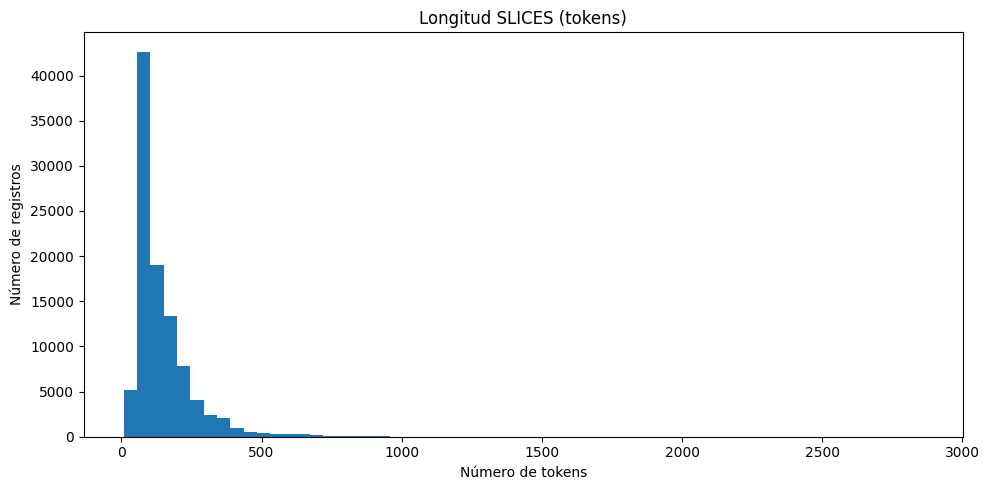

In [13]:
token_percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 99.5, 99.9, 100]
slices_token_summary = df_base["slices_n_tokens"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .995, .999]).to_frame("slices_n_tokens")
display(slices_token_summary)
print("Percentiles solicitados:")
display(df_base["slices_n_tokens"].quantile(np.array(token_percentiles) / 100).rename(index=lambda x: f"{x*100:g}%").to_frame())

strict_is_true = df_base["slices_valid"].eq(True)
df_base["strict_valid_group"] = np.where(strict_is_true, "strict_valid", "not_strict_or_missing")
comparison_columns = [c for c in [
    "nsites", "n_elements", "spg", "energy_corrected_per_atom", "slices_n_tokens", "composition_count"
] if c in df_base.columns]
# composition_count se añadirá en la sección 15; esta comparación se completa después.
strict_comparison = df_base.groupby("strict_valid_group")[comparison_columns].agg(["count", "median", "mean"])
display(strict_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
df_base["slices_n_tokens"].dropna().plot(kind="hist", bins=60, ax=ax)
ax.set(title="Longitud SLICES (tokens)", xlabel="Número de tokens", ylabel="Número de registros")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "slices_token_length.png", dpi=160)
plt.show()


## 12. Outlier analysis

Para targets, volumen por átomo, `nsites` y longitud SLICES se calculan mínimo, cuartiles, IQR, percentiles y máximo. Se marca como estadísticamente atípico si cae fuera de la cerca IQR o fuera de `[P1, P99]`. Son indicadores de inspección, no motivos automáticos de exclusión. Los histogramas se guardan en `figures/`.

,column,n,min,Q1,median,Q3,IQR,lower_IQR_fence,upper_IQR_fence,P1,P99,P99_9,max,outlier_count
0,energy_corrected_per_atom,99998,-13.977843,-6.539840e+00,-5.010035,-3.822726,2.717113,-10.615509,0.252943,-10.358484,-1.374918,-0.794647,-0.202257,2000
1,e_form,99998,-5.718934,-7.067917e-01,-0.200384,0.115768,0.822560,-1.940631,1.349608,-3.242085,1.979836,3.222372,5.438597,10350
2,e_above_hull,99998,0.000000,4.292431e-02,0.148499,0.400831,0.357907,-0.493936,0.937692,0.000000,2.406186,3.549685,5.448516,10838
3,e_phase_separation,99998,-4.218167,4.154596e-02,0.147276,0.398516,0.356970,-0.493909,0.933971,-0.032749,2.406093,3.549685,5.448516,11885
4,band_gap_ind,99998,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.831415,5.783657,8.942700,11239
5,band_gap_dir,99998,0.000000,0.000000e+00,0.000100,0.019800,0.019800,-0.029700,0.049500,0.000000,3.891551,5.838908,8.957500,17570
6,total_mag,99998,-55.000000,-1.000000e-07,0.000001,0.965839,0.965839,-1.448759,2.414598,-0.271515,18.181776,51.999992,144.363710,17303
7,dos_ef,99998,-4.320755,2.444969e+00,4.533049,8.388064,5.943095,-6.469674,17.302706,-0.076344,37.562921,80.569024,268.545070,8589
8,volume_per_atom,99998,4.331431,1.655306e+01,22.222806,29.078073,12.525012,-2.234458,47.865591,8.241612,53.282578,85.786656,210.112597,2710
9,nsites,99998,1.000000,5.000000e+00,8.000000,12.000000,7.000000,-5.500000,22.500000,3.000000,56.000000,96.000000,152.000000,5448


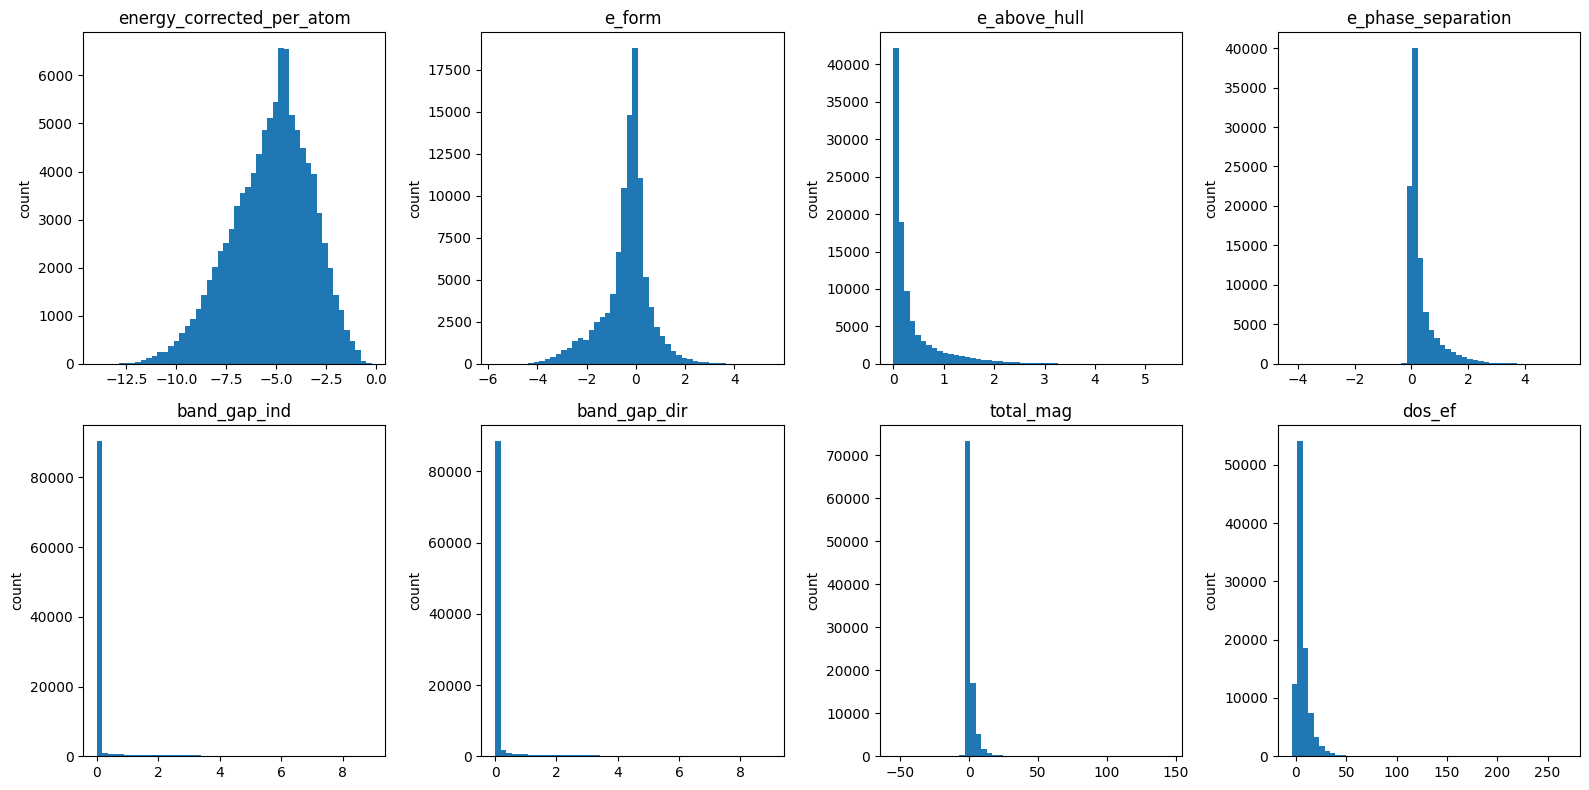

In [14]:
OUTLIER_COLUMNS = [column for column in [
    "energy_corrected_per_atom", "e_form", "e_above_hull", "e_phase_separation",
    "band_gap_ind", "band_gap_dir", "total_mag", "dos_ef", "volume_per_atom",
    "nsites", "slices_n_tokens",
] if column in df_base.columns]
outlier_rows = []
for column in OUTLIER_COLUMNS:
    values = pd.to_numeric(df_base[column], errors="coerce")
    finite = values[np.isfinite(values)]
    if finite.empty:
        outlier_rows.append({"column": column, "n": 0})
        df_base[f"outlier_{column}"] = False
        continue
    q1, median, q3 = finite.quantile([.25, .5, .75])
    iqr = q3 - q1
    p1, p99, p999 = finite.quantile([.01, .99, .999])
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_base[f"outlier_{column}"] = values.notna() & (
        (values < lower_iqr) | (values > upper_iqr) | (values < p1) | (values > p99)
    )
    outlier_rows.append({
        "column": column, "n": int(finite.size), "min": float(finite.min()),
        "Q1": float(q1), "median": float(median), "Q3": float(q3), "IQR": float(iqr),
        "lower_IQR_fence": float(lower_iqr), "upper_IQR_fence": float(upper_iqr),
        "P1": float(p1), "P99": float(p99), "P99_9": float(p999),
        "max": float(finite.max()), "outlier_count": int(df_base[f"outlier_{column}"].sum()),
    })
outlier_thresholds = pd.DataFrame(outlier_rows)
display(outlier_thresholds)

plot_targets = [column for column in [
    "energy_corrected_per_atom", "e_form", "e_above_hull", "e_phase_separation",
    "band_gap_ind", "band_gap_dir", "total_mag", "dos_ef",
] if column in df_base.columns]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, column in zip(axes.flat, plot_targets):
    values = pd.to_numeric(df_base[column], errors="coerce")
    values = values[np.isfinite(values)]
    ax.hist(values, bins=50)
    ax.set_title(column)
    ax.set_ylabel("count")
for ax in axes.flat[len(plot_targets):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "main_target_histograms.png", dpi=160)
plt.show()


## 13. Quality flags

Se calculan grupos de composición tras ignorar solo las copias exactas ya reportadas. La misma composición nunca se usa como clave de deduplicación. Se crean flags para energía, composición, metadatos, SLICES estricta y valores extremos; `quality_flags` compacta los nombres que aplican a cada fila.

In [15]:
composition_counts = df_base.groupby("composition_key", dropna=True).size()
df_base["composition_count"] = df_base["composition_key"].map(composition_counts).astype("Int64")
df_base["is_singleton_composition"] = df_base["composition_count"].eq(1).fillna(False)
df_base["is_polymorph_candidate"] = df_base["composition_count"].ge(2).fillna(False)

# Completar la comparación de SLICES strict-valid incluyendo el conteo de composición.
strict_comparison_columns = [c for c in [
    "nsites", "n_elements", "spg", "energy_corrected_per_atom", "slices_n_tokens", "composition_count"
] if c in df_base.columns]
strict_comparison = df_base.groupby("strict_valid_group")[strict_comparison_columns].agg(["count", "median", "mean"])

# Duplicados exploratorios dentro de una misma composición. Se marcan, nunca se borran por sí solos.
df_base["same_composition_same_slices"] = False
df_base["same_composition_same_prototype"] = False
df_base["near_duplicate_energy"] = False
has_comp = df_base["composition_key"].notna()
valid_slice = df_base["slices"].notna()
df_base.loc[has_comp & valid_slice, "same_composition_same_slices"] = (
    df_base.loc[has_comp & valid_slice].duplicated(["composition_key", "slices"], keep=False)
)
if "prototype_id" in df_base.columns:
    has_proto = has_comp & df_base["prototype_id"].notna()
    df_base.loc[has_proto, "same_composition_same_prototype"] = (
        df_base.loc[has_proto].duplicated(["composition_key", "prototype_id"], keep=False)
    )
for _, group in df_base.loc[has_comp & df_base["energy_corrected_per_atom"].notna()].groupby("composition_key"):
    if len(group) < 2:
        continue
    ordered = group["energy_corrected_per_atom"].sort_values()
    close_positions = np.flatnonzero(np.diff(ordered.to_numpy(dtype=float)) < 1e-6)
    if len(close_positions):
        flagged_indices = set(ordered.index[close_positions]) | set(ordered.index[close_positions + 1])
        df_base.loc[list(flagged_indices), "near_duplicate_energy"] = True

outlier_flag_columns = [f"outlier_{column}" for column in OUTLIER_COLUMNS]
df_base["extreme_target"] = df_base[outlier_flag_columns].any(axis=1) if outlier_flag_columns else False
flag_map = {
    "exact_duplicate_row": "exact_duplicate_row",
    "duplicate_mat_id_conflict": "duplicate_mat_id_conflict",
    "negative_e_above_hull": "flag_negative_e_above_hull",
    "negative_band_gap_ind": "flag_negative_band_gap_ind",
    "negative_band_gap_dir": "flag_negative_band_gap_dir",
    "negative_dos_ef": "flag_negative_dos_ef",
    "invalid_nsites": "invalid_nsites", "invalid_volume": "invalid_volume",
    "invalid_volume_per_atom": "invalid_volume_per_atom", "invalid_spg": "invalid_spg",
    "invalid_n_elements": "invalid_n_elements",
    "energy_inconsistent": None,
    "composition_inconsistent": None,
    "extreme_target": "extreme_target",
    "strict_slices_invalid": None,
    "same_composition_same_slices": "same_composition_same_slices",
    "same_composition_same_prototype": "same_composition_same_prototype",
    "near_duplicate_energy": "near_duplicate_energy",
}
energy_inconsistent = energy_inconsistent_mask.reindex(df_base.index, fill_value=False).fillna(False)
composition_inconsistent = composition_inconsistency_mask.reindex(df_base.index, fill_value=False).fillna(False)
strict_invalid = ~df_base["slices_valid"].eq(True).fillna(False)
quality_flag_values = []
for idx, row in df_base.iterrows():
    flags = []
    for name, column in flag_map.items():
        if column is not None and bool(row.get(column, False)):
            flags.append(name)
    if bool(energy_inconsistent.loc[idx]): flags.append("energy_inconsistent")
    if bool(composition_inconsistent.loc[idx]): flags.append("composition_inconsistent")
    if bool(strict_invalid.loc[idx]): flags.append("strict_slices_invalid")
    quality_flag_values.append(";".join(flags))
df_base["quality_flags"] = quality_flag_values
df_base["n_quality_flags"] = df_base["quality_flags"].map(lambda value: len(value.split(";")) if value else 0)
df_base["has_quality_flags"] = df_base["n_quality_flags"].gt(0)

print("Filas con uno o más quality flags:", int(df_base["has_quality_flags"].sum()))
display(df_base.loc[df_base["has_quality_flags"], [
    "mat_id", "composition_key", "quality_flags", "n_quality_flags"
]].head(15))


Filas con uno o más quality flags: 51597


,mat_id,composition_key,quality_flags,n_quality_flags
3,agm003886200,Br2 Mn1 Sr1,extreme_target,1
6,agm022402795,Cd1 Cs1 F7 Hf1,extreme_target,1
8,agm007306622,H8 Mn1 Pd2 Pr1,extreme_target,1
10,agm004037245,As2 Mn1 P1,extreme_target,1
12,agm076235267,H2 Te1 Zr1,extreme_target,1
14,agm002903143,Ba2 W1 Y1,extreme_target,1
15,agm004993628,Au1 Ca1 Na1 O2,extreme_target,1
16,agm011046679,Fe2 O6 Pr1 Sr1,extreme_target,1
20,agm005153693,Ac1 Pr1 Sm2 Y5,extreme_target,1
21,agm008271218,Al5 Fe9 Sm6,extreme_target,1


## 14. Build clean dataset

`critical_quality_pass` exige ID, SLICES no vacío, composición, `nsites > 0`, energía corregida por átomo finita, SLICES basic-valid y ausencia de conflicto grave de `mat_id`. Las inconsistencias no críticas, targets secundarios ausentes, outliers y SLICES strict-invalid se mantienen marcados. El CSV rechazado conserva motivo y datos clave; `alexandria_audit_all.csv` conserva todas las filas de entrada y flags, incluidas copias completas detectadas.

In [16]:
energy_numeric = pd.to_numeric(df_base["energy_corrected_per_atom"], errors="coerce")
energy_finite = energy_numeric.notna() & np.isfinite(energy_numeric)
mat_id_present = df_base["mat_id"].notna() & df_base["mat_id"].astype("string").str.strip().ne("")
slices_present = df_base["slices"].notna() & df_base["slices"].astype("string").str.strip().ne("")
composition_present = df_base["composition_key"].notna() & df_base["composition_key"].astype("string").str.strip().ne("")
nsites_valid = df_base["nsites"].notna() & np.isfinite(df_base["nsites"]) & (df_base["nsites"] > 0)
basic_valid = df_base["slices_basic_valid"].eq(True).fillna(False)
no_mat_id_conflict = ~df_base["duplicate_mat_id_conflict"].fillna(False)

df_base["critical_quality_pass"] = (
    mat_id_present & slices_present & composition_present & nsites_valid
    & energy_finite & basic_valid & no_mat_id_conflict
)

def rejection_reasons(row):
    reasons=[]
    if bool(row.get("duplicate_mat_id_conflict", False)): reasons.append("duplicate_mat_id_conflict")
    if pd.isna(row.get("mat_id")): reasons.append("missing_mat_id")
    if pd.isna(row.get("slices")) or not str(row.get("slices", "")).strip(): reasons.append("missing_or_empty_slices")
    if pd.isna(row.get("composition_key")) or not str(row.get("composition_key", "")).strip(): reasons.append("missing_composition_key")
    if pd.isna(row.get("nsites")) or not np.isfinite(row.get("nsites", np.nan)) or row.get("nsites", 0) <= 0: reasons.append("invalid_nsites")
    energy=row.get("energy_corrected_per_atom", np.nan)
    if pd.isna(energy) or not np.isfinite(energy): reasons.append("missing_or_nonfinite_energy_corrected_per_atom")
    basic_value = row.get("slices_basic_valid")
    if pd.isna(basic_value) or not bool(basic_value): reasons.append("slices_basic_invalid_or_missing")
    return ";".join(reasons)

df_base["rejection_reason"] = df_base.apply(rejection_reasons, axis=1)
clean_all = df_base.loc[df_base["critical_quality_pass"]].copy()
clean_basic = clean_all.loc[clean_all["slices_basic_valid"].eq(True)].copy()
clean_strict = clean_basic.loc[clean_basic["slices_valid"].eq(True)].copy()

# Las copias exactas retiradas se incluyen en el reporte de rechazos, además de las filas que fallan criterios críticos.
exact_duplicate_rows["rejection_reason"] = "exact_duplicate_row"
base_rejected = df_base.loc[~df_base["critical_quality_pass"]].copy()
rejected = pd.concat([base_rejected, exact_duplicate_rows], ignore_index=True, sort=False)
rejected_columns = [column for column in [
    "source_row_index", "mat_id", "composition_key", "slices", "rejection_reason", "quality_flags"
] if column in rejected.columns]
rejected_report = rejected[rejected_columns].copy()

# Asignar conteos y flags de auditoría también a las copias exactas usando composition_key.
exact_duplicate_rows["composition_count"] = exact_duplicate_rows["composition_key"].map(composition_counts).astype("Int64")
exact_duplicate_rows["is_singleton_composition"] = exact_duplicate_rows["composition_count"].eq(1).fillna(False)
exact_duplicate_rows["is_polymorph_candidate"] = exact_duplicate_rows["composition_count"].ge(2).fillna(False)
exact_duplicate_rows["critical_quality_pass"] = False
exact_duplicate_rows["quality_flags"] = exact_duplicate_rows.get("quality_flags", "")
exact_duplicate_rows["n_quality_flags"] = exact_duplicate_rows.get("n_quality_flags", 0)
exact_duplicate_rows["has_quality_flags"] = True

audit_all = pd.concat([df_base, exact_duplicate_rows], ignore_index=True, sort=False).sort_values("source_row_index")
print("Filas de entrada:", input_row_count)
print("Critical-quality passed:", len(clean_all))
print("Rejected (incluye copias exactas y fallos críticos):", len(rejected_report))


Filas de entrada: 99998
Critical-quality passed: 99998
Rejected (incluye copias exactas y fallos críticos): 0


## 15. Singleton compositions

`composition_count` cuenta entradas que pasan el criterio crítico y tienen la misma clave de composición. Una composición singleton aparece una sola vez en este shard; no se afirma que sea una estructura única fuera del dataset. Las composiciones repetidas se conservan completas.

In [17]:
singletons = clean_all.loc[clean_all["composition_count"].eq(1)].copy()
print("Singleton compositions:", len(singletons))
print("Composiciones singleton únicas:", singletons["composition_key"].nunique())
display(singletons[["mat_id", "formula", "composition_key", "composition_count"]].head())


Singleton compositions: 93507
Composiciones singleton únicas: 93507


,mat_id,formula,composition_key,composition_count
0,agm005737469,Sr(Cd5Rh)2,Cd10 Rh2 Sr1,1
1,agm002510391,Li3CaPt,Ca1 Li3 Pt1,1
2,agm004513860,Nd2TiGa4Pt3,Ga4 Nd2 Pt3 Ti1,1
3,agm003886200,SrMnBr2,Br2 Mn1 Sr1,1
4,agm034649907,Na2Tb3SmSe6,Na2 Se6 Sm1 Tb3,1


## 16. Polymorph candidates

Se seleccionan composiciones con al menos dos registros críticos. Se usa el nombre `polymorph_candidates`: varias entradas y SLICES distintos pueden ser duplicados estructurales o variaciones de representación. La confirmación requiere recuperar estructuras completas y usar `StructureMatcher` en otra fase.

In [18]:
polymorph_candidates = clean_all.loc[clean_all["composition_count"].ge(2)].copy()
composition_summary = polymorph_candidates.groupby("composition_key", dropna=True).agg(
    n_structures=("mat_id", "size"),
    n_unique_slices=("slices", "nunique"),
    n_unique_prototypes=("prototype_id", "nunique"),
    min_energy_corrected_per_atom=("energy_corrected_per_atom", "min"),
    max_energy_corrected_per_atom=("energy_corrected_per_atom", "max"),
).reset_index()
composition_summary["energy_range"] = (
    composition_summary["max_energy_corrected_per_atom"]
    - composition_summary["min_energy_corrected_per_atom"]
)
polymorph_candidates = polymorph_candidates.merge(
    composition_summary[["composition_key", "n_structures", "n_unique_slices", "n_unique_prototypes"]],
    on="composition_key", how="left", validate="many_to_one",
)

print("Composiciones candidatas:", composition_summary["composition_key"].nunique())
print("Filas en grupos candidatos:", len(polymorph_candidates))
display(composition_summary.sort_values("n_structures", ascending=False).head(20))


Composiciones candidatas: 3081
Filas en grupos candidatos: 6491


,composition_key,n_structures,n_unique_slices,n_unique_prototypes,min_energy_corrected_per_atom,max_energy_corrected_per_atom,energy_range
596,B1 C1,12,12,12,-7.606047,-7.507634,0.098414
634,B7 C5,11,11,8,-7.447406,-7.266246,0.181160
632,B5 C7,8,8,8,-7.883717,-7.712207,0.171510
2756,O2 Si1,7,7,7,-8.376402,-8.327019,0.049383
1447,Co5 Li9 Mn2 O16,7,7,7,-6.567837,-6.503071,0.064766
2079,Hg1,7,7,7,-0.302944,-0.202257,0.100687
619,B2 C1,5,5,5,-7.234778,-6.981627,0.253152
3042,Sm1 Tb1 Tm2,5,5,4,-4.574044,-4.548475,0.025569
1580,Cu1 Mg1,5,5,5,-2.891503,-2.150016,0.741487
2344,K1,5,5,4,-1.097730,-1.046993,0.050737


## 17. Preliminary relative energies

Dentro de cada composición candidata se calcula `delta_e_ev_atom` respecto a la menor energía corregida por átomo del grupo; se convierte también a meV/átomo y se añade un ranking ascendente. Es un ΔE **preliminar**, sin deduplicación estructural. No se quita ningún registro por tener ΔE alto.

In [19]:
group_min_energy = polymorph_candidates.groupby("composition_key")[
    "energy_corrected_per_atom"
].transform("min")
polymorph_candidates["delta_e_ev_atom"] = (
    polymorph_candidates["energy_corrected_per_atom"] - group_min_energy
)
polymorph_candidates["delta_e_mev_atom"] = polymorph_candidates["delta_e_ev_atom"] * 1000
polymorph_candidates["relative_energy_rank"] = polymorph_candidates.groupby("composition_key")[
    "energy_corrected_per_atom"
].rank(method="min", ascending=True).astype("Int64")

candidate_group_counts = composition_summary["n_structures"].value_counts().sort_index()
exact_group_counts = {n: int(candidate_group_counts.get(n, 0)) for n in (2, 3, 4)}
n_ge_5 = int((composition_summary["n_structures"] >= 5).sum())
max_candidates = int(composition_summary["n_structures"].max()) if not composition_summary.empty else 0
candidate_structure_count = int(composition_summary["n_structures"].sum())
print("Composiciones con exactamente 2 estructuras:", exact_group_counts[2])
print("Composiciones con exactamente 3 estructuras:", exact_group_counts[3])
print("Composiciones con exactamente 4 estructuras:", exact_group_counts[4])
print("Composiciones con >=5 estructuras:", n_ge_5)
print("Máximo de estructuras por composición:", max_candidates)
print("Total de estructuras en grupos candidatos:", candidate_structure_count)

delta_bins = [
    ("<= 1 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 1),
    ("<= 5 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 5),
    ("<= 10 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 10),
    ("<= 25 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 25),
    ("<= 50 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 50),
    ("<= 100 meV/atom", polymorph_candidates["delta_e_mev_atom"] <= 100),
    ("> 100 meV/atom", polymorph_candidates["delta_e_mev_atom"] > 100),
]
delta_counts = pd.DataFrame([
    {"threshold": label, "row_count": int(mask.sum()), "composition_count": int(polymorph_candidates.loc[mask, "composition_key"].nunique())}
    for label, mask in delta_bins
])
print("Distribución de delta_e_mev_atom:")
display(polymorph_candidates["delta_e_mev_atom"].describe().to_frame())
display(delta_counts)


Composiciones con exactamente 2 estructuras: 2826
Composiciones con exactamente 3 estructuras: 215
Composiciones con exactamente 4 estructuras: 28
Composiciones con >=5 estructuras: 12
Máximo de estructuras por composición: 12
Total de estructuras en grupos candidatos: 6491
Distribución de delta_e_mev_atom:


,delta_e_mev_atom
count,6491.000000
mean,109.944361
std,245.919809
min,0.000000
25%,0.000000
50%,2.143714
75%,107.473375
max,3270.459000


,threshold,row_count,composition_count
0,<= 1 meV/atom,3171,3081
1,<= 5 meV/atom,3356,3081
2,<= 10 meV/atom,3510,3081
3,<= 25 meV/atom,3861,3081
4,<= 50 meV/atom,4233,3081
5,<= 100 meV/atom,4799,3081
6,> 100 meV/atom,1692,1586


## 18. Save datasets and audit reports

Se escriben los siete CSV principales especificados y tablas auxiliares que permiten revisar coerciones, missing values, duplicados, composición, energía y outliers. También se guarda un JSON de resumen y figuras PNG. Cada archivo se escribe en `OUTPUT_DIR`, que será `outputs/` o una subcarpeta `cleaning_run_...` si los resultados anteriores se deben preservar.

In [20]:
# Tablas de salida principal.
clean_all.to_csv(OUTPUT_DIR / "alexandria_clean_all.csv", index=False)
clean_basic.to_csv(OUTPUT_DIR / "alexandria_clean_basic.csv", index=False)
clean_strict.to_csv(OUTPUT_DIR / "alexandria_clean_strict.csv", index=False)
singletons.to_csv(OUTPUT_DIR / "alexandria_singleton_compositions.csv", index=False)
polymorph_candidates.to_csv(OUTPUT_DIR / "alexandria_polymorph_candidates.csv", index=False)
composition_summary.to_csv(OUTPUT_DIR / "alexandria_composition_summary.csv", index=False)
rejected_report.to_csv(OUTPUT_DIR / "alexandria_rejected.csv", index=False)

# Archivo completo para auditoría; incluye también copias exactas señaladas como rechazadas.
audit_all.to_csv(OUTPUT_DIR / "alexandria_audit_all.csv", index=False)
missing_audit.to_csv(OUTPUT_DIR / "missing_values_audit.csv", index=False)
numeric_coercion_audit.to_csv(OUTPUT_DIR / "numeric_coercion_audit.csv", index=False)
duplicate_mat_id_report.to_csv(OUTPUT_DIR / "duplicate_mat_id_conflicts.csv", index=False)
slices_duplicate_report.to_csv(OUTPUT_DIR / "duplicate_slices_review.csv", index=False)
composition_inconsistency_report.to_csv(OUTPUT_DIR / "composition_inconsistencies.csv", index=False)
energy_inconsistency_report.to_csv(OUTPUT_DIR / "energy_inconsistencies.csv", index=False)
crystal_report.to_csv(OUTPUT_DIR / "crystallographic_flags_summary.csv", index=False)
outlier_thresholds.to_csv(OUTPUT_DIR / "outlier_thresholds.csv", index=False)
energy_correlation.to_csv(OUTPUT_DIR / "energy_correlation.csv")
delta_counts.to_csv(OUTPUT_DIR / "delta_e_threshold_counts.csv", index=False)
strict_comparison.to_csv(OUTPUT_DIR / "strict_validity_comparison.csv")

# Resumen serializable para automatizar comparaciones entre ejecuciones.
summary_payload = {
    "input_csv": str(INPUT_CSV),
    "output_dir": str(OUTPUT_DIR),
    "input_rows": int(input_row_count),
    "input_columns": int(input_column_count),
    "critical_quality_passed": int(len(clean_all)),
    "rejected_rows_reported": int(len(rejected_report)),
    "unique_mat_id": int(df["mat_id"].nunique(dropna=True)),
    "unique_slices": int(df["slices"].nunique(dropna=True)),
    "unique_composition_key": int(df["composition_key"].nunique(dropna=True)),
    "singleton_compositions": int(singletons["composition_key"].nunique()),
    "candidate_compositions": int(composition_summary["composition_key"].nunique()),
    "candidate_structures": int(len(polymorph_candidates)),
    "basic_valid_rows": int(df["slices_basic_valid"].eq(True).sum()),
    "strict_valid_rows": int(df["slices_valid"].eq(True).sum()),
    "energy_nan_rows": int(df["energy_corrected_per_atom"].isna().sum()),
    "energy_infinite_rows": int(count_infinite(df["energy_corrected_per_atom"])),
    "energy_inconsistency_rows": int(len(energy_inconsistency_report)),
    "composition_inconsistency_rows": int(len(composition_inconsistency_report)),
    "rows_with_quality_flags": int(df_base["has_quality_flags"].sum()),
    "graph_method": "econnn",
    "strategy": 4,
    "delta_e_note": "Preliminary; structural deduplication with StructureMatcher has not been performed.",
}
with (OUTPUT_DIR / "cleaning_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary_payload, handle, ensure_ascii=False, indent=2)

print("Datasets and audit outputs saved under:", OUTPUT_DIR)


Datasets and audit outputs saved under: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/notebooks_processing/outputs/cleaning_run_20261005_212323


## 19. Final cleaning report

Se imprime el funnel de calidad, el detalle de candidatos y los thresholds de ΔE. Los conteos no determinan automáticamente qué subconjunto se utilizará para ChemBERTa; los CSV `basic` y `strict` quedan disponibles para compararlos después.

In [21]:
composition_counts_after_clean = clean_all.groupby("composition_key").size()
strict_valid_n = int(df["slices_valid"].eq(True).sum())
basic_valid_n = int(df["slices_basic_valid"].eq(True).sum())
energy_bad_n = int(df["energy_corrected_per_atom"].isna().sum() + count_infinite(df["energy_corrected_per_atom"]))
energy_inconsistency_n = int(len(energy_inconsistency_report))
composition_inconsistency_n = int(len(composition_inconsistency_report))
invalid_crystal_n = int(df_base[crystal_flags].any(axis=1).sum())
flagged_rows_n = int(df_base["has_quality_flags"].sum())

print("==================================================")
print("ALEXANDRIA DATA CLEANING SUMMARY")
print("==================================================")
print(f"Input rows:                         {input_row_count:>8}")
print(f"Critical-quality passed:            {len(clean_all):>8}")
print(f"Rejected:                           {len(rejected_report):>8}")
print()
print(f"Unique mat_id:                      {df['mat_id'].nunique(dropna=True):>8}")
print(f"Unique SLICES:                      {df['slices'].nunique(dropna=True):>8}")
print(f"Unique compositions:                {df['composition_key'].nunique(dropna=True):>8}")
print()
print(f"Singleton compositions:             {len(singletons['composition_key'].unique()):>8}")
print(f"Compositions with >=2 candidates:   {len(composition_summary):>8}")
print(f"Structures in candidate groups:     {len(polymorph_candidates):>8}")
print()
print(f"Basic-valid SLICES:                 {basic_valid_n:>8}")
print(f"Strict-valid SLICES:                {strict_valid_n:>8}")
print()
print(f"Energy NaN or infinite:             {energy_bad_n:>8}")
print(f"Energy inconsistencies:             {energy_inconsistency_n:>8}")
print(f"Composition inconsistencies:        {composition_inconsistency_n:>8}")
print(f"Invalid crystallographic metadata:  {invalid_crystal_n:>8}")
print(f"Rows with quality flags:            {flagged_rows_n:>8}")
print()
print("Candidatos por tamaño de grupo:")
print(f"Exactly 2: {exact_group_counts[2]}")
print(f"Exactly 3: {exact_group_counts[3]}")
print(f"Exactly 4: {exact_group_counts[4]}")
print(f">= 5:      {n_ge_5}")
print(f"Maximum:   {max_candidates}")
print(f"Rows involved: {candidate_structure_count}")
print()
print("Top 20 composition candidates:")
display(composition_summary.sort_values("n_structures", ascending=False).head(20))
print("\nOutput files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(f"- {path.relative_to(OUTPUT_DIR)} ({path.stat().st_size / 1_000_000:.2f} MB)")


ALEXANDRIA DATA CLEANING SUMMARY
Input rows:                            99998
Critical-quality passed:               99998
Rejected:                                  0

Unique mat_id:                         99998
Unique SLICES:                         99998
Unique compositions:                   96588

Singleton compositions:                93507
Compositions with >=2 candidates:       3081
Structures in candidate groups:         6491

Basic-valid SLICES:                    99998
Strict-valid SLICES:                   98394

Energy NaN or infinite:                    0
Energy inconsistencies:                    0
Composition inconsistencies:               0
Invalid crystallographic metadata:         0
Rows with quality flags:               51597

Candidatos por tamaño de grupo:
Exactly 2: 2826
Exactly 3: 215
Exactly 4: 28
>= 5:      12
Maximum:   12
Rows involved: 6491

Top 20 composition candidates:


,composition_key,n_structures,n_unique_slices,n_unique_prototypes,min_energy_corrected_per_atom,max_energy_corrected_per_atom,energy_range
596,B1 C1,12,12,12,-7.606047,-7.507634,0.098414
634,B7 C5,11,11,8,-7.447406,-7.266246,0.181160
632,B5 C7,8,8,8,-7.883717,-7.712207,0.171510
2756,O2 Si1,7,7,7,-8.376402,-8.327019,0.049383
1447,Co5 Li9 Mn2 O16,7,7,7,-6.567837,-6.503071,0.064766
2079,Hg1,7,7,7,-0.302944,-0.202257,0.100687
619,B2 C1,5,5,5,-7.234778,-6.981627,0.253152
3042,Sm1 Tb1 Tm2,5,5,4,-4.574044,-4.548475,0.025569
1580,Cu1 Mg1,5,5,5,-2.891503,-2.150016,0.741487
2344,K1,5,5,4,-1.097730,-1.046993,0.050737



Output files:
- alexandria_audit_all.csv (130.85 MB)
- alexandria_clean_all.csv (130.85 MB)
- alexandria_clean_basic.csv (130.85 MB)
- alexandria_clean_strict.csv (129.11 MB)
- alexandria_composition_summary.csv (0.19 MB)
- alexandria_polymorph_candidates.csv (7.81 MB)
- alexandria_rejected.csv (0.00 MB)
- alexandria_singleton_compositions.csv (123.25 MB)
- cleaning_summary.json (0.00 MB)
- composition_inconsistencies.csv (0.00 MB)
- crystallographic_flags_summary.csv (0.00 MB)
- delta_e_threshold_counts.csv (0.00 MB)
- duplicate_mat_id_conflicts.csv (0.00 MB)
- duplicate_slices_review.csv (0.00 MB)
- energy_correlation.csv (0.00 MB)
- energy_inconsistencies.csv (0.00 MB)
- figures/main_target_histograms.png (0.13 MB)
- figures/slices_token_length.png (0.04 MB)
- missing_values_audit.csv (0.00 MB)
- numeric_coercion_audit.csv (0.00 MB)
- outlier_thresholds.csv (0.00 MB)
- strict_validity_comparison.csv (0.00 MB)


## Interpretación y siguiente fase

- `alexandria_clean_all.csv` y `alexandria_clean_basic.csv` contienen las filas que pasan el criterio crítico, que ya exige SLICES basic-valid. Ambos se guardan explícitamente para que la elección del dataset quede visible y reproducible.
- `alexandria_clean_strict.csv` es la vista más restrictiva, añadida para comparar el efecto de la validación completa.
- `alexandria_singleton_compositions.csv` identifica composiciones vistas una vez en este shard.
- `alexandria_polymorph_candidates.csv` y `alexandria_composition_summary.csv` son agrupaciones preliminares, no una afirmación de polimorfismo confirmado. `delta_e_mev_atom` necesita la deduplicación estructural posterior antes de interpretarse como estabilidad relativa entre polimorfos.
- `alexandria_rejected.csv` enumera cada fila excluida y su motivo; `alexandria_audit_all.csv` conserva todas las filas y flags para rastreo. Los demás CSV/PNG/JSON son reportes de auditoría.

La siguiente fase puede recuperar las estructuras originales de Alexandria, aplicar `StructureMatcher` dentro de cada composición y recalcular el conjunto de candidatos antes de definir targets de estabilidad o entrenar modelos.
